## **Reproducing and Extending a Dynamical Model of Dopamine Regulation During Levodopa Therapy**

### **Student name:** Nahal Habibizadeh 
### **Student ID:** 20942866

In [1]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
%matplotlib inline


### Model Parameters

All values taken from Best et al. (2009) Table 2 and Reed et al. (2012) Tables A2–A5.

In [2]:
# Best et al. 2009 — tyrosine hydroxylase
th_vmax  = 125.0
th_ktyr  = 46.0
th_kbh4  = 60.0
th_ki_c  = 110.0
th_ki_t  = 160.0

# AADC
adc_vmax = 10000.0
adc_km   = 130.0

# VMAT
vmat_vmax = 7082.0
vmat_km   = 3.0
vmat_leak = 40.0

# DAT
dat_vmax = 8000.0
dat_km   = 0.2

# DRR (biopterin recycling)
drr_vf   = 5000.0
drr_vb   = 80.0
drr_kbh2 = 100.0
drr_knadph = 75.0
drr_kbh4 = 10.0
drr_knadp = 75.0
nadph = 100.0
nadp  = 100.0

# Tyrosine transport + pool
btyr       = 97.0
tyr_vmax   = 400.0
tyr_km     = 64.0
k_pool_fwd = 6.0
k_pool_rev = 0.6

# Catabolism / removal
kcat_tyr  = 0.2
kcat_cda  = 10.0
ecat_vmax = 30.0
ecat_km   = 3.0
kcat_hva  = 3.45
kcat_pool = 0.2
k_rem0    = 400.0

fr = 1.0  # tonic firing rate (normalised to 1)

### Reaction Velocities

The dopamine pathway: tyrosine → L-DOPA (TH, rate-limiting) → cytosolic DA (AADC) → vesicular DA (VMAT) → extracellular DA (release) → reuptake (DAT).

In [3]:
def tyr_import(bld):
    return tyr_vmax * bld / (tyr_km + bld)

def th_rate(tyr, bh4, cda, eda):
    si   = 0.56 / (1.0 + (tyr / th_ki_t)**2)
    en   = 0.002
    rat  = eda / (en + 1e-12)
    auto = (4.5 / (1.0 + rat**4)) + 0.5
    mm   = th_vmax * tyr * bh4 / ((tyr + th_ktyr) * (bh4 + th_kbh4) * (1.0 + cda / th_ki_c))
    return si * auto * mm

def drr_rate(bh2, bh4):
    fwd = drr_vf * bh2 * nadph / ((drr_kbh2 + bh2) * (drr_knadph + nadph))
    bwd = drr_vb * bh4 * nadp  / ((drr_kbh4  + bh4) * (drr_knadp  + nadp))
    return fwd - bwd

def aadc_rate(ld):
    return adc_vmax * ld / (adc_km + ld)

def vmat_rate(cda, vda):
    return vmat_vmax * cda / (vmat_km + cda) - vmat_leak * vda

def dat_rate(eda):
    return dat_vmax * eda / (dat_km + eda)

def eda_catab(eda):
    return ecat_vmax * eda / (ecat_km + eda)


### ODE System

Nine-variable system: `[bh2, bh4, tyr, ldopa, cda, vda, eda, hva, tyrpool]`.  
Parameter `f` is the fraction of SNc cells still alive (1 = healthy, → 0 = advanced PD).  
The removal rate scales as `k_rem = k_rem0 / f` — as terminal density falls, released DA is increasingly likely to diffuse out rather than be recaptured.

In [4]:
def da_odes(t, y, f=1.0, ld_func=None):
    bh2, bh4, tyr, ld, cda, vda, eda, hva, tpool = [max(v, 0) for v in y]

    vt   = tyr_import(btyr)
    vth  = th_rate(tyr, bh4, cda, eda)
    vdrr = drr_rate(bh2, bh4)
    va   = aadc_rate(ld)
    vm   = vmat_rate(cda, vda)
    vd   = dat_rate(eda)
    ve   = eda_catab(eda)

    ld_in = 0.0
    if ld_func is not None:
        sld  = ld_func(t)
        styr, stryp = 63.0, 82.0
        denom = 1.0 + styr/64.0 + stryp/15.0
        ld_in = 1840.0 * sld / (32.0 * denom + sld)

    kr = k_rem0 / max(f, 0.001)

    return [
        vth - vdrr,
        vdrr - vth,
        vt - vth - k_pool_fwd*tyr + k_pool_rev*tpool - kcat_tyr*tyr,
        vth - va + ld_in,
        va - vm + vd - kcat_cda*cda,
        vm - fr*vda,
        fr*vda - vd - ve - kr*eda,
        kcat_cda*cda + ve - kcat_hva*hva,
        k_pool_fwd*tyr - k_pool_rev*tpool - kcat_pool*tpool
    ]

def to_ss(f=1.0):
    y0  = [41.0, 319.0, 126.0, 0.36, 2.65, 81.0, 0.002, 7.68, 952.0]
    sol = solve_ivp(da_odes, [0, 200], y0, args=(f, None),
                    method='BDF', rtol=1e-8, atol=1e-10, max_step=0.5)
    return sol.y[:, -1]


### Levodopa Pharmacokinetic Profile

Serum LD after oral administration: rapid absorption, ~90 min half-life (Reed et al. 2012).

In [5]:
def ld_serum(t, t0=5.0, cpeak=100.0, hl=1.5):
    if t < t0:
        return 0.0
    dt = t - t0
    kd = np.log(2) / hl
    kr = 5.0
    return cpeak * (np.exp(-kd*dt) - np.exp(-kr*dt)) * kr / (kr - kd)


### 1 — Steady-State Verification

Running the model to equilibrium under tonic firing. Extracellular DA is the most clinically relevant variable — it should sit around 2–3 nM.

In [6]:
ss0 = to_ss(f=1.0)
vnames   = ['bh2','bh4','tyr','ldopa','cda','vda','eda','hva','tyrpool']
pub_vals = [41.0, 319.0, 126.0, 0.36, 2.65, 81.0, 0.002, 7.68, 952.0]

print(f"{'Variable':<12} {'This model':>12} {'Published':>12}")
print('-'*38)
for nm, mv, pv in zip(vnames, ss0, pub_vals):
    print(f"{nm:<12} {mv:>12.4f} {pv:>12.4f}")


Variable       This model    Published
--------------------------------------
bh2                3.2571      41.0000
bh4              356.7429     319.0000
tyr              114.9038     126.0000
ldopa              0.5963       0.3600
cda                4.4596       2.6500
vda              103.2650      81.0000
eda                0.0026       0.0020
hva               12.9339       7.6800
tyrpool          861.7788     952.0000


### 2 — Substrate Inhibition of Tyrosine Hydroxylase

TH is the rate-limiting step. At high tyrosine it actually *slows down* (uncompetitive substrate inhibition), which insulates DA synthesis from dietary tyrosine fluctuations — a nice built-in buffer.

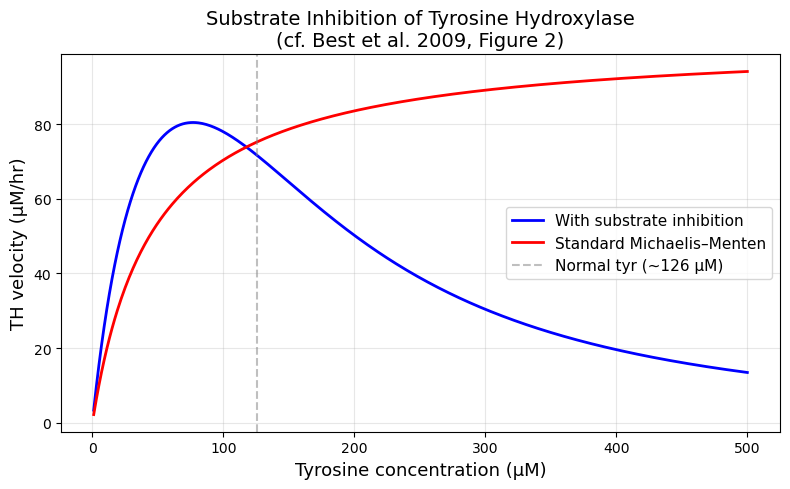

In [7]:
tyr_sweep = np.linspace(1, 500, 500)
bh4_ref, cda_ref, eda_ref = 319.0, 2.65, 0.002

v_si  = [th_rate(x, bh4_ref, cda_ref, eda_ref) for x in tyr_sweep]
v_std = [th_vmax * x * bh4_ref /
         ((x + th_ktyr)*(bh4_ref + th_kbh4)*(1.0 + cda_ref/th_ki_c))
         for x in tyr_sweep]

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(tyr_sweep, v_si,  'b-', lw=2, label='With substrate inhibition')
ax.plot(tyr_sweep, v_std, 'r-', lw=2, label='Standard Michaelis–Menten')
ax.axvline(126, color='gray', ls='--', alpha=0.5, label='Normal tyr (~126 μM)')
ax.set_xlabel('Tyrosine concentration (μM)', fontsize=13)
ax.set_ylabel('TH velocity (μM/hr)', fontsize=13)
ax.set_title('Substrate Inhibition of Tyrosine Hydroxylase\n(cf. Best et al. 2009, Figure 2)', fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('fig_substrate_inhibition.png', dpi=200, bbox_inches='tight')
plt.show()


### 3 — Autoreceptor Homeostasis

D2 autoreceptors on the terminal feed back onto TH: when extracellular DA is high, synthesis is suppressed, and vice versa. The result is that extracellular DA changes much less than firing rate does.

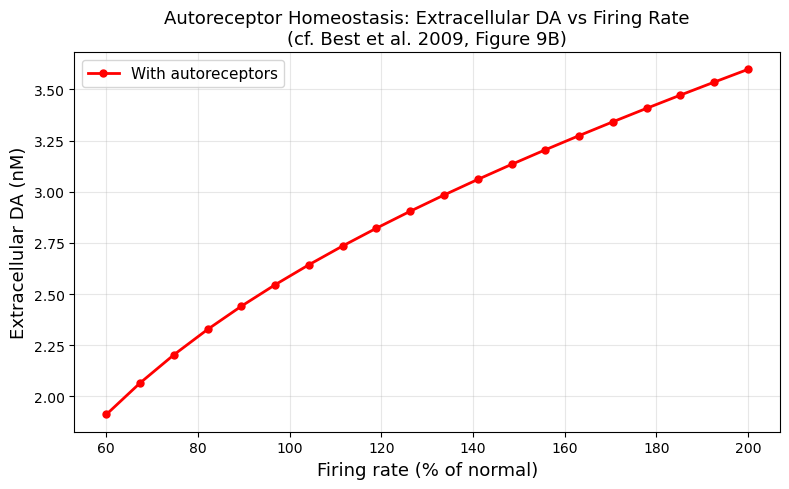

In [8]:
global fr
fr_sweep = np.linspace(0.6, 2.0, 20)
eda_auto = []

for frac in fr_sweep:
    fr = frac
    y0 = [41.0, 319.0, 126.0, 0.36, 2.65, 81.0, 0.002, 7.68, 952.0]
    sol = solve_ivp(lambda t, y: da_odes(t, y, f=1.0),
                    [0, 100], y0, method='BDF',
                    rtol=1e-8, atol=1e-10, max_step=1.0)
    eda_auto.append(sol.y[6, -1] * 1000)

fr = 1.0

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(fr_sweep * 100, eda_auto, 'r-o', ms=5, lw=2, label='With autoreceptors')
ax.set_xlabel('Firing rate (% of normal)', fontsize=13)
ax.set_ylabel('Extracellular DA (nM)', fontsize=13)
ax.set_title('Autoreceptor Homeostasis: Extracellular DA vs Firing Rate\n(cf. Best et al. 2009, Figure 9B)', fontsize=13)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('fig_autoreceptor_homeostasis.png', dpi=200, bbox_inches='tight')
plt.show()


### 4 — Passive Stabilization of Extracellular DA

As SNc cells die, extracellular DA should stay nearly constant until ~80% are gone. This is passive stabilization: release and reuptake both scale with `f`, so their ratio stays roughly fixed. This is why PD symptoms don't appear until late-stage disease.

  f=0.010  eda=1.4384 nM
  f=0.020  eda=1.8443 nM
  f=0.030  eda=2.0288 nM
  f=0.040  eda=2.1384 nM
  f=0.050  eda=2.2123 nM
  f=0.070  eda=2.3066 nM
  f=0.090  eda=2.3646 nM
  f=0.110  eda=2.4041 nM
  f=0.130  eda=2.4328 nM
  f=0.150  eda=2.4545 nM
  f=0.170  eda=2.4716 nM
  f=0.190  eda=2.4854 nM
  f=0.200  eda=2.4913 nM
  f=0.250  eda=2.5144 nM
  f=0.300  eda=2.5301 nM
  f=0.350  eda=2.5416 nM
  f=0.400  eda=2.5503 nM
  f=0.450  eda=2.5572 nM
  f=0.500  eda=2.5627 nM
  f=0.550  eda=2.5673 nM
  f=0.600  eda=2.5711 nM
  f=0.650  eda=2.5744 nM
  f=0.700  eda=2.5771 nM
  f=0.750  eda=2.5796 nM
  f=0.800  eda=2.5817 nM
  f=0.850  eda=2.5836 nM
  f=0.900  eda=2.5853 nM
  f=0.950  eda=2.5868 nM
  f=1.000  eda=2.5882 nM


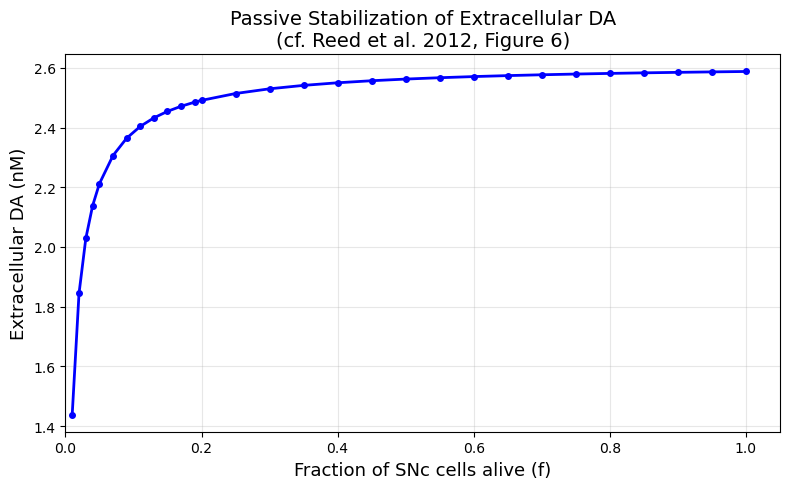

In [9]:
deg_vals = np.concatenate([
    np.arange(0.01, 0.05, 0.01),
    np.arange(0.05, 0.2,  0.02),
    np.arange(0.2,  1.01, 0.05)
])

eda_ss_vals = []
for fv in deg_vals:
    s = to_ss(f=fv)
    eda_ss_vals.append(s[6])
    print(f"  f={fv:.3f}  eda={s[6]*1000:.4f} nM")

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(deg_vals, np.array(eda_ss_vals)*1000, 'b-o', ms=4, lw=2)
ax.set_xlabel('Fraction of SNc cells alive (f)', fontsize=13)
ax.set_ylabel('Extracellular DA (nM)', fontsize=13)
ax.set_title('Passive Stabilization of Extracellular DA\n(cf. Reed et al. 2012, Figure 6)', fontsize=14)
ax.set_xlim([0, 1.05])
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('fig_passive_stabilization.png', dpi=200, bbox_inches='tight')
plt.show()


### 5 — Extracellular DA During an LD Dose

Simulating what happens to extracellular DA in the striatum after a levodopa dose, for several levels of SNc degeneration. The dashed line is the therapeutic threshold — time above it is the therapeutic window.

  running f=1.0...
  running f=0.2...
  running f=0.1...
  running f=0.05...
  running f=0.01...


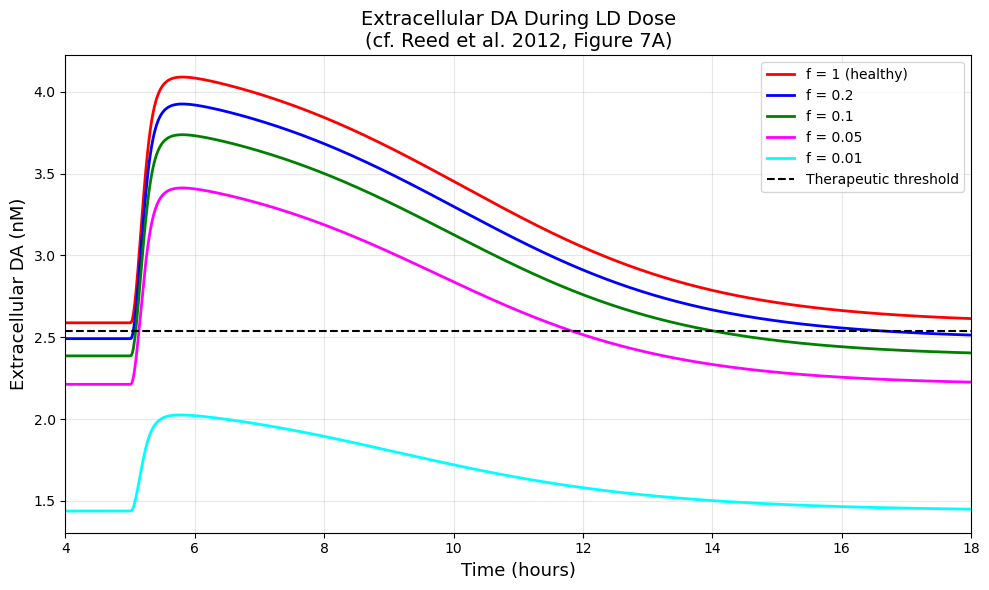

In [10]:
deg_levels = [1.0, 0.2, 0.1, 0.05, 0.01]
clrs   = ['red', 'blue', 'green', 'magenta', 'cyan']
lbls   = ['f = 1 (healthy)', 'f = 0.2', 'f = 0.1', 'f = 0.05', 'f = 0.01']
t_dose = 5.0
tspan  = [0, 20]
tpts   = np.linspace(0, 20, 2000)

fig, ax = plt.subplots(figsize=(10, 6))
base_eda = {}
curves   = {}

for fv, cl, lb in zip(deg_levels, clrs, lbls):
    print(f"  running f={fv}...")
    s0 = to_ss(f=fv)
    base_eda[fv] = s0[6]
    ld_fn = lambda t, td=t_dose: ld_serum(t, t0=td)
    sol = solve_ivp(da_odes, tspan, s0, args=(fv, ld_fn),
                    method='BDF', rtol=1e-8, atol=1e-10,
                    t_eval=tpts, max_step=0.05)
    ec = sol.y[6] * 1000
    curves[fv] = ec
    ax.plot(sol.t, ec, color=cl, lw=2, label=lb)

thresh = (base_eda[1.0] + base_eda[0.2]) / 2.0 * 1000
ax.axhline(thresh, color='black', ls='--', lw=1.5, label='Therapeutic threshold')
ax.set_xlabel('Time (hours)', fontsize=13)
ax.set_ylabel('Extracellular DA (nM)', fontsize=13)
ax.set_title('Extracellular DA During LD Dose\n(cf. Reed et al. 2012, Figure 7A)', fontsize=14)
ax.legend(fontsize=10, loc='upper right')
ax.set_xlim([4, 18])
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('fig_ld_dose_time_courses.png', dpi=200, bbox_inches='tight')
plt.show()


### 6 — Therapeutic Time Window vs. Disease Progression

Sweeping over `f` and computing how long each curve stays above the therapeutic threshold.

  f=0.01  window=0.00 hr
  f=0.02  window=2.55 hr
  f=0.05  window=6.67 hr
  f=0.1  window=8.89 hr
  f=0.15  window=10.30 hr
  f=0.2  window=11.51 hr


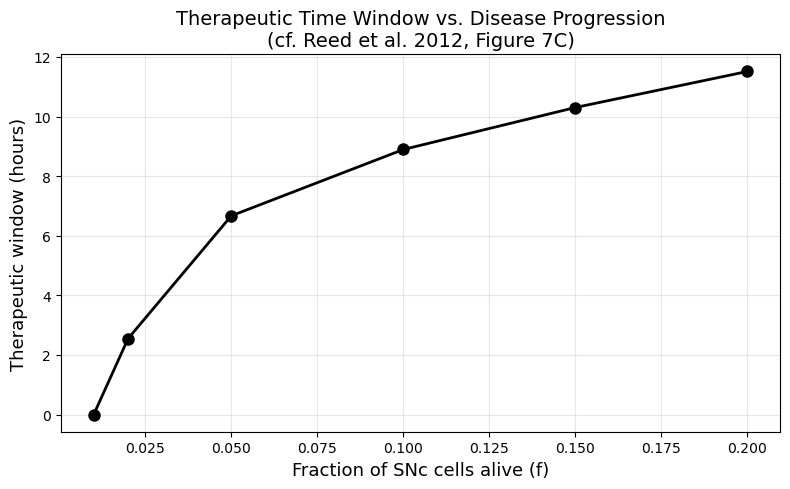

In [11]:
f_win  = [0.01, 0.02, 0.05, 0.1, 0.15, 0.2]
tspan2 = [0, 25]
tpts2  = np.linspace(0, 25, 3000)

s_norm = to_ss(f=1.0)
s_02   = to_ss(f=0.2)
thr2   = (s_norm[6] + s_02[6]) / 2.0

win_hrs = []
for fv in f_win:
    s0    = to_ss(f=fv)
    ld_fn = lambda t, td=t_dose: ld_serum(t, t0=td)
    sol   = solve_ivp(da_odes, tspan2, s0, args=(fv, ld_fn),
                      method='BDF', rtol=1e-8, atol=1e-10,
                      t_eval=tpts2, max_step=0.05)
    above = sol.y[6] > thr2
    if np.any(above):
        idx = np.where(above)[0]
        w = sol.t[idx[-1]] - sol.t[idx[0]]
    else:
        w = 0.0
    win_hrs.append(w)
    print(f"  f={fv}  window={w:.2f} hr")

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(f_win, win_hrs, 'ko-', ms=8, lw=2)
ax.set_xlabel('Fraction of SNc cells alive (f)', fontsize=13)
ax.set_ylabel('Therapeutic window (hours)', fontsize=13)
ax.set_title('Therapeutic Time Window vs. Disease Progression\n(cf. Reed et al. 2012, Figure 7C)', fontsize=14)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('fig_therapeutic_window.png', dpi=200, bbox_inches='tight')
plt.show()


### 7 — Novel Extension: Dopamine-Modulated Neural Excitability

The published model ends at extracellular DA. This extension asks: what does that DA signal actually *do* to a downstream striatal neuron?

A leaky integrator is coupled to the DA output via a saturating gain function:

$$\tau_n \frac{dV}{dt} = -V + g(D_{\mathrm{ext}}) \cdot I_{\mathrm{base}}$$

$$g(D) = g_0 \left(1 + \alpha \frac{D}{K_D + D}\right)$$

The key question: does the gain profile (and its variability) depend non-monotonically on `f`? That would help explain why dyskinesias emerge preferentially at *intermediate* degeneration.

  f=0.2...
  f=0.1...
  f=0.05...
  f=0.01...


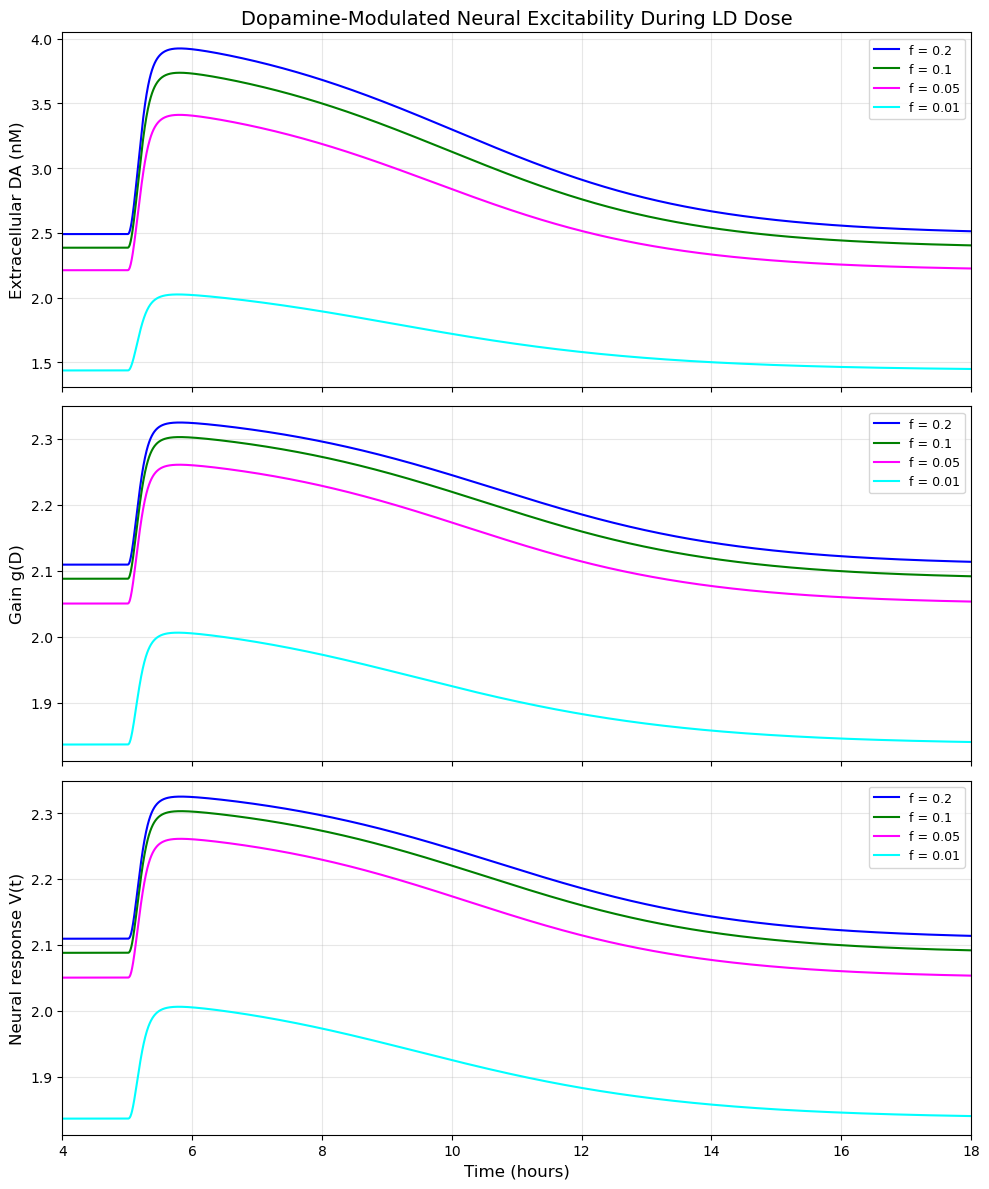

In [12]:
tau_n  = 0.02
g0     = 1.0
alph   = 2.0
kd_gn  = 2.0
ibase  = 1.0

def gain(d_nm):
    return g0 * (1.0 + alph * d_nm / (kd_gn + d_nm))

f_ext   = [0.2, 0.1, 0.05, 0.01]
col_ext = ['blue', 'green', 'magenta', 'cyan']
lbl_ext = ['f = 0.2', 'f = 0.1', 'f = 0.05', 'f = 0.01']
tspan3  = [0, 20]
tpts3   = np.linspace(0, 20, 5000)

fig, axes = plt.subplots(3, 1, figsize=(10, 12), sharex=True)

for fv, cl, lb in zip(f_ext, col_ext, lbl_ext):
    print(f"  f={fv}...")
    s0    = to_ss(f=fv)
    ld_fn = lambda t, td=t_dose: ld_serum(t, t0=td)
    sol   = solve_ivp(da_odes, tspan3, s0, args=(fv, ld_fn),
                      method='BDF', rtol=1e-8, atol=1e-10,
                      t_eval=tpts3, max_step=0.05)

    dnm  = sol.y[6] * 1000
    tarr = sol.t
    gt   = np.array([gain(d) for d in dnm])

    V    = np.zeros_like(tarr)
    V[0] = gain(dnm[0]) * ibase
    for i in range(1, len(tarr)):
        dt   = tarr[i] - tarr[i-1]
        V[i] = V[i-1] + dt * (-V[i-1] + gain(dnm[i]) * ibase) / tau_n

    axes[0].plot(tarr, dnm, color=cl, lw=1.5, label=lb)
    axes[1].plot(tarr, gt,  color=cl, lw=1.5, label=lb)
    axes[2].plot(tarr, V,   color=cl, lw=1.5, label=lb)

axes[0].set_ylabel('Extracellular DA (nM)', fontsize=12)
axes[0].set_title('Dopamine-Modulated Neural Excitability During LD Dose', fontsize=14)
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)
axes[1].set_ylabel('Gain g(D)', fontsize=12)
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)
axes[2].set_ylabel('Neural response V(t)', fontsize=12)
axes[2].set_xlabel('Time (hours)', fontsize=12)
axes[2].legend(fontsize=9)
axes[2].grid(True, alpha=0.3)
for ax in axes:
    ax.set_xlim([4, 18])
plt.tight_layout()
plt.savefig('fig_neural_coupling.png', dpi=200, bbox_inches='tight')
plt.show()


#### Gain Analysis — Peak and Variability vs. f

Sweeping `f` to see how the gain profile changes with disease stage. The non-monotonic shape — peak at intermediate degeneration — is the key result.

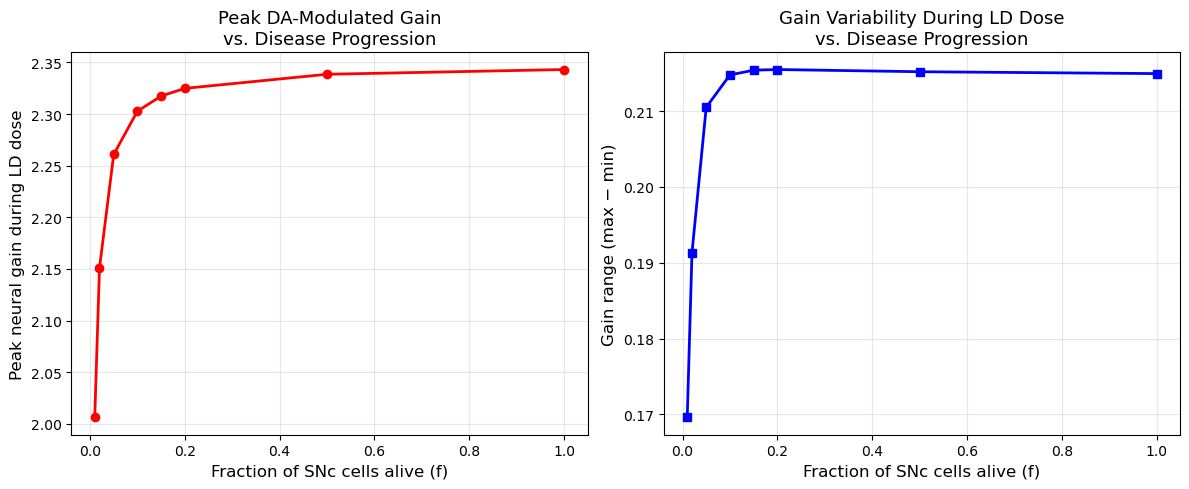

In [13]:
f_scan     = np.array([0.01, 0.02, 0.05, 0.1, 0.15, 0.2, 0.5, 1.0])
pk_gains   = []
gn_ranges  = []

for fv in f_scan:
    s0    = to_ss(f=fv)
    ld_fn = lambda t, td=t_dose: ld_serum(t, t0=td)
    sol   = solve_ivp(da_odes, tspan3, s0, args=(fv, ld_fn),
                      method='BDF', rtol=1e-8, atol=1e-10,
                      t_eval=tpts3, max_step=0.05)
    gs = np.array([gain(d) for d in sol.y[6]*1000])
    pk_gains.append(gs.max())
    gn_ranges.append(gs.max() - gs.min())

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
ax1.plot(f_scan, pk_gains,  'ro-', ms=6, lw=2)
ax1.set_xlabel('Fraction of SNc cells alive (f)', fontsize=12)
ax1.set_ylabel('Peak neural gain during LD dose', fontsize=12)
ax1.set_title('Peak DA-Modulated Gain\nvs. Disease Progression', fontsize=13)
ax1.grid(True, alpha=0.3)
ax2.plot(f_scan, gn_ranges, 'bs-', ms=6, lw=2)
ax2.set_xlabel('Fraction of SNc cells alive (f)', fontsize=12)
ax2.set_ylabel('Gain range (max − min)', fontsize=12)
ax2.set_title('Gain Variability During LD Dose\nvs. Disease Progression', fontsize=13)
ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('fig_gain_analysis.png', dpi=200, bbox_inches='tight')
plt.show()
